#CNN

##Kütüphane

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, ReLU
import matplotlib.pyplot as plt

##Veri

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
X_train.shape

(60000, 28, 28, 1)

In [ ]:
X_train = X_train.reshape(-1,28,28,1) / 255
X_test = X_test.reshape(-1,28,28,1) / 255

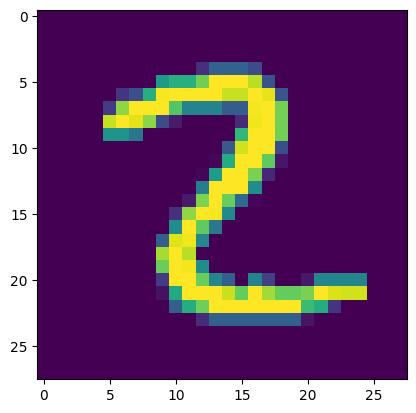

In [ ]:
plt.imshow(X_train[76])

##Model

In [ ]:
cnn_model = Sequential([
    Conv2D(32,(3,3), activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3)),
    ReLU(),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3)),
    ReLU(),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(32,activation='relu'),
    Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

##Eğitim

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cnn_model.fit(X_train,y_train, epochs=200,batch_size=64,validation_data=(X_test, y_test))
cnn_model.save('/content/drive/MyDrive/Tech İstanbul/cnn.keras')

Epoch 1/200
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step - accuracy: 0.8236 - loss: 0.7634 - val_accuracy: 0.8989 - val_loss: 0.8006
Epoch 2/200
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step - accuracy: 0.8826 - loss: 0.5745 - val_accuracy: 0.9273 - val_loss: 0.6577
Epoch 3/200
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.8684 - loss: 0.5156 - val_accuracy: 0.9090 - val_loss: 0.9604
Epoch 4/200
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.8956 - loss: 0.5034 - val_accuracy: 0.8876 - val_loss: 0.4791
Epoch 5/200
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9222 - loss: 0.3965 - val_accuracy: 0.9192 - val_loss: 0.5120
Epoch 6/200
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9218 - loss: 0.3988 - val_accuracy: 0.8929 - val_loss: 0.5484
Epoch 7/200
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - accuracy: 0.9241 - loss: 0.3949 - val_accuracy: 0.9381 - val_loss: 0.6135
Epoch 8/200
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9295 -

##Filtre Görselleştirme

In [ ]:
layer_index = 5
layer = cnn_model.layers[layer_index]

In [ ]:
filters, biases = layer.get_weights()


In [ ]:
n_filters = filters.shape[3]

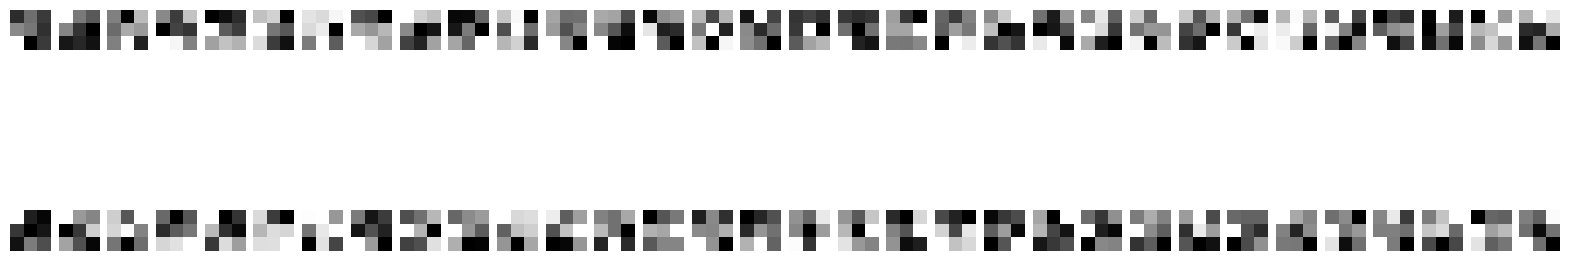

In [ ]:
plt.figure(figsize=(20,10))

for i in range(n_filters):
  f = filters[:,:,:,i]
  plt.subplot(4,32,i+1)
  plt.imshow(f[:,:,0],cmap='gray')
  plt.axis('off')
plt.show()

##Gerçek Zamanlı Test

In [ ]:
from PIL import Image
import numpy as np

In [ ]:
def tahmin(image_path):
  img = Image.open(image_path).convert('L')
  img = img.resize((28,28))
  img_array = np.array(img)

  img_array = img_array.reshape(-1,28,28,1)/255

  prediction = cnn_model.predict(img_array)

  predicted_number = np.argmax(prediction)

  print(predicted_number)

  plt.imshow(img,cmap='gray')
  plt.title(f"Tahmin : {predicted_number}")
  plt.axis('off')
  plt.show()

Tahmin etmek istediğiniz görselin dosya yolunu giriniz : 0.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
7


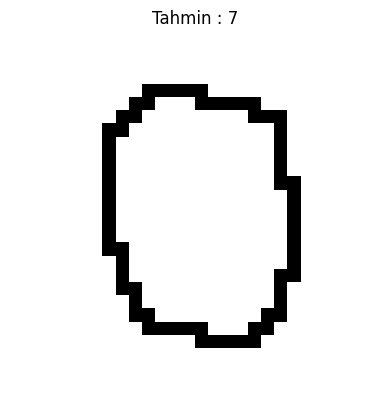

In [ ]:
giris = input("Tahmin etmek istediğiniz görselin dosya yolunu giriniz : ")
tahmin(giris)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')